### Packages

In [216]:
import pickle
import numpy as np
import math
import matplotlib.pyplot as plt
import tarfile
import urllib.request
import os
import shutil
from tqdm import tqdm
from torch_gradient_computations import ComputeGradsWithTorch
import copy



In [217]:
import torch


In [218]:

FILEPATH="Datasets/cifar-10-batches-py/" # we add the directory path first 


### Read the file, this will be used to access the train, val and test batches.

In [219]:

def LoadBatch(filename):
    with open(filename, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")

    X = batch[b"data"].astype(np.float64).T / 255.0   # 3072 x 10000  divide by 255.0 so to keep everything small 
    y = np.array(batch[b"labels"])                    # length 10000, since we have 1000 images

    K = 10
    n = X.shape[1]
    Y = np.zeros((K, n), dtype=X.dtype)
    Y[y, np.arange(n)] = 1 # each column represent the class representation of one image 

    return X, Y, y

 ### Normalize the data: X_train, X_validation, X_test

In [220]:
def normalize(X, mean_X, std_X):
    return (X - mean_X) / std_X

### Access the training, validation and test data.

In [221]:


X_train,Y_train,y_train=LoadBatch(FILEPATH+"data_batch_1")

X_validation,Y_validation,y_validation=LoadBatch(FILEPATH+"data_batch_2")

X_test,Y_test,y_test=LoadBatch(FILEPATH+"test_batch")

d = X_train.shape[0]

mean_X = np.mean(X_train, axis=1).reshape(d, 1)
std_X  = np.std(X_train, axis=1).reshape(d, 1)

X_train = normalize(X_train, mean_X, std_X)
X_validation = normalize(X_validation, mean_X, std_X)
X_test = normalize(X_test, mean_X, std_X)

### Initialize parameters $W$ and $b$

In [222]:
def init_network(X_train):

    K = 10
    d = X_train.shape[0]

    rng = np.random.default_rng()
    BitGen = type(rng.bit_generator)
    seed = 42
    rng.bit_generator.state = BitGen(seed).state

    init_net = {
        'W': 0.01 * rng.standard_normal((K, d)),
        'b': np.zeros((K, 1))
    }
    return init_net



### Softmax function

In [223]:
def softmax(s):
    s = s - np.max(s, axis=0, keepdims=True)   # stability
    exp_s = np.exp(s)
    return exp_s / np.sum(exp_s, axis=0, keepdims=True)


### Define a function that applies:

\begin{equation*}
\begin{aligned}
\mathbf{s} & =W \mathbf{x}+\mathbf{b} \\
\mathbf{p} & =\operatorname{SOFTMAX}(\mathbf{s})
\end{aligned}
\end{equation*}

In [224]:
def ApplyNetwork(X,network):


    W=network['W']
    b=network['b']

    s=np.dot(W,X)
    P=softmax(s)
    return P

In [225]:
network=init_network(X_train)
P = ApplyNetwork(X_train[:, 0:100], network)
print(P.shape)
print(np.sum(P[:, 0]))

(10, 100)
1.0


### Compute

\begin{equation*}
J(\mathcal{D}, \lambda, W, b)=\frac{1}{|\mathcal{D}|} \sum_{(\mathbf{x}, y) \in \mathcal{D}} -\log \left(p_y\right)
\end{equation*}



In [226]:
def ComputeLoss(P, y):
    n = P.shape[1]
    correct_class_probs = P[y, np.arange(n)]
    L = -np.mean(np.log(correct_class_probs))
    return L



In [227]:
def computeAccuracy(P, y):
    y_pred = np.argmax(P, axis=0)
    accuracy = np.mean(y_pred == y)
    return 100*accuracy

Now let us connect this to $W$ and $b$. Since

\begin{equation*}
s=W x+b
\end{equation*}

we use the chain rule.
Because $s_k=w_k^T x+b_k$, we get

\begin{equation*}
\frac{\partial s_k}{\partial w_k}=x, \quad \frac{\partial s_k}{\partial b_k}=1
\end{equation*}

and therefore

\begin{equation*}
\begin{gathered}
\frac{\partial l}{\partial W}=\frac{\partial l}{\partial s} \frac{\partial s}{\partial W}=(p-y) x^T \\
\frac{\partial l}{\partial b}=\frac{\partial l}{\partial s}=p-y
\end{gathered}
\end{equation*}


So the logic is:

\begin{equation*}
\ell \rightarrow \frac{\partial \ell}{\partial s}=p-y
\end{equation*}

\begin{equation*}
\begin{gathered}
\frac{\partial J}{\partial W}=\frac{1}{n} G X^T+2 \lambda W \\
\frac{\partial J}{\partial b}=\frac{1}{n} \sum_{i=1}^n g^{(i)}
\end{gathered}
\end{equation*}


### Here we calculate the gradient of $W$ and $b$

In [228]:

def BackwardPass(X, Y, P, network, lam):
    W = network['W']
    n = X.shape[1]

    G = P - Y

    grads = {}
    grads['W'] = (G @ X.T) / n + 2 * lam * W
    grads['b'] = np.sum(G, axis=1, keepdims=True) / n

    return grads

In [229]:

rng = np.random.default_rng()
BitGen = type(rng.bit_generator)
seed = 42
rng.bit_generator.state = BitGen(seed).state

d_small = 10
n_small = 3
lam = 0.0

small_net = {}
small_net['W'] = 0.01 * rng.standard_normal(size=(10, d_small))
small_net['b'] = np.zeros((10, 1))

X_small = X_train[0:d_small, 0:n_small]
Y_small = Y_train[:, 0:n_small]
y_small = y_train[0:n_small]

P_small = ApplyNetwork(X_small, small_net)

my_grads = BackwardPass(X_small, Y_small, P_small, small_net, lam)
torch_grads = ComputeGradsWithTorch(X_small, y_small, small_net)

print("max abs diff W:", np.max(np.abs(my_grads['W'] - torch_grads['W'])))
print("max abs diff b:", np.max(np.abs(my_grads['b'] - torch_grads['b'])))

def relative_error(a, b, eps=1e-10):
    return np.abs(a - b) / np.maximum(eps, np.abs(a) + np.abs(b))

rel_W = relative_error(my_grads['W'], torch_grads['W'])
rel_b = relative_error(my_grads['b'], torch_grads['b'])

print("max relative error W:", np.max(rel_W))
print("max relative error b:", np.max(rel_b))

max abs diff W: 1.1102230246251565e-16
max abs diff b: 5.551115123125783e-17
max relative error W: 2.1004151634013915e-15
max relative error b: 1.190200411005617e-16


In [230]:
lam = 0.1

P_small = ApplyNetwork(X_small, small_net)
my_grads = BackwardPass(X_small, Y_small, P_small, small_net, lam)
torch_grads = ComputeGradsWithTorch(X_small, y_small, small_net, lam)

print("max abs diff W:", np.max(np.abs(my_grads['W'] - torch_grads['W'])))
print("max abs diff b:", np.max(np.abs(my_grads['b'] - torch_grads['b'])))
print("max relative error W:", np.max(relative_error(my_grads['W'], torch_grads['W'])))
print("max relative error b:", np.max(relative_error(my_grads['b'], torch_grads['b'])))

max abs diff W: 1.1102230246251565e-16
max abs diff b: 5.551115123125783e-17
max relative error W: 4.5829256268066545e-15
max relative error b: 1.190200411005617e-16


### Task 1.8 

\begin{equation*}
\begin{aligned}
W^{(t+1)} & =W^{(t)}-\eta \frac{\partial J\left(B^{(t+1)}, \lambda, W, b\right)}{\partial W} \\
b^{(t+1)} & =b^{(t)}-\eta \frac{\partial J\left(B^{(t+1)}, \lambda, W, b\right)}{\partial b}
\end{aligned}
\end{equation*}

In [231]:
def ComputeCost(X, y, network, lam):
    P = ApplyNetwork(X, network)
    loss = ComputeLoss(P, y)
    cost = loss + lam * np.sum(network['W'] ** 2)
    return cost, loss

In [232]:


def MiniBatchGD(X_train, Y_train, y_train, X_val, y_val, GDparams, init_net, lam, rng=None):
    n_batch = GDparams['n_batch']
    eta = GDparams['eta']
    n_epochs = GDparams['n_epochs']

    trained_net = copy.deepcopy(init_net)

    n = X_train.shape[1]

    train_costs = []
    train_losses = []
    val_costs = []
    val_losses = []

    for epoch in (range(n_epochs)):

        perm = rng.permutation(n) 

        X_train = X_train[:, perm] #shuffle 
      
        Y_train = Y_train[:, perm] #shuffle 
      
        y_train = y_train[perm] #shuffle 
      

        for j in range(n // n_batch): #loop over batches
            j_start = j * n_batch
            j_end = (j + 1) * n_batch

            Xbatch = X_train[:, j_start:j_end]
            Ybatch = Y_train[:, j_start:j_end]

            Pbatch = ApplyNetwork(Xbatch, trained_net)
            grads = BackwardPass(Xbatch, Ybatch, Pbatch, trained_net, lam)

            trained_net['W'] -= eta * grads['W']
            trained_net['b'] -= eta * grads['b']

        train_cost, train_loss = ComputeCost(X_train, y_train, trained_net, lam)
        val_cost, val_loss = ComputeCost(X_val, y_val, trained_net, lam)

        train_costs.append(train_cost)
        train_losses.append(train_loss)
        val_costs.append(val_cost)
        val_losses.append(val_loss)

        #print(f"Epoch {epoch+1}/{n_epochs}: train cost={train_cost:.4f}, val cost={val_cost:.4f}")

    history = {
        'train_costs': train_costs,
        'train_losses': train_losses,
        'val_costs': val_costs,
        'val_losses': val_losses
    }

    return trained_net, history

In [233]:
GDparams = {
    'n_batch': 100,
    'eta': 0.001,
    'n_epochs': 40
}

rng = np.random.default_rng(42)


trained_net, history = MiniBatchGD(
    X_train, Y_train, y_train,
    X_validation, y_validation,
    GDparams, network, lam=0.0, rng=rng
)



### Plotting the training and validation cost over epochs

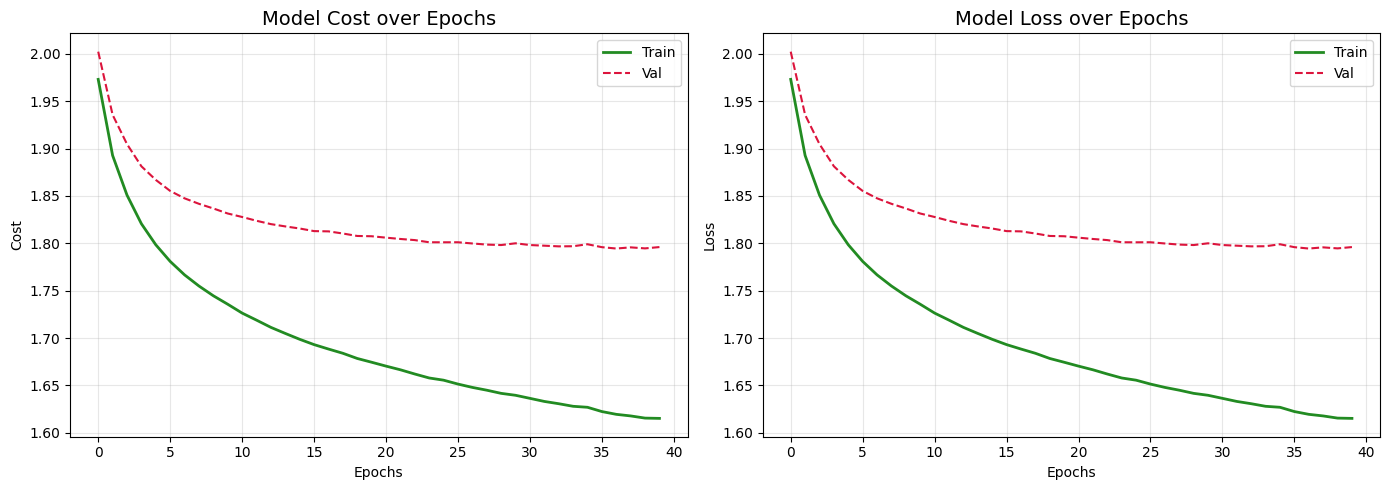

In [234]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Cost
ax1.plot(history['train_costs'], label='Train', color='forestgreen', lw=2)
ax1.plot(history['val_costs'], label='Val', color='crimson', linestyle='--')
ax1.set_title('Model Cost over Epochs', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Cost')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(history['train_losses'], label='Train', color='forestgreen', lw=2)
ax2.plot(history['val_losses'], label='Val', color='crimson', linestyle='--')
ax2.set_title('Model Loss over Epochs', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout() 
plt.show()

### Test the accuracy on batch_test

In [235]:
def EvaluateSet(X, y, network, lam):
    P = ApplyNetwork(X, network)
    acc = computeAccuracy(P, y)
    loss = ComputeLoss(P, y)
    cost = loss + lam * np.sum(network['W']**2)
    return {"acc": acc, "loss": loss, "cost": cost}


test_metrics = EvaluateSet(X_test, y_test, trained_net, lam)
print("Final test accuracy:", test_metrics["acc"])
print("Final test loss:", test_metrics["loss"])
print("Final test cost:", test_metrics["cost"])

Final test accuracy: 39.15
Final test loss: 1.7711280677439365
Final test cost: 2.1542134529709314


In [236]:

def show_weight_images(trained_net, class_names=None, figsize=(12, 5)):
    W = trained_net['W']   # shape: (10, 3072)

    Ws = W.T.reshape((32, 32, 3, 10), order='F')
    W_im = np.transpose(Ws, (1, 0, 2, 3))

    if class_names is None:
        class_names = [
            "airplane", "automobile", "bird", "cat", "deer",
            "dog", "frog", "horse", "ship", "truck"
        ]

    fig, axs = plt.subplots(2, 5, figsize=figsize)

    for i, ax in enumerate(axs.flat):
        w_im = W_im[:, :, :, i]

        w_min = np.min(w_im)
        w_max = np.max(w_im)
        w_im_norm = (w_im - w_min) / (w_max - w_min + 1e-12)


        ax.imshow(w_im_norm)
        ax.set_title(class_names[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
def run_experiments():
    experiments = [
        {"lam": 0.0, "eta": 0.1,   "n_batch": 100, "n_epochs": 40},
        {"lam": 0.0, "eta": 0.001, "n_batch": 100, "n_epochs": 40},
        {"lam": 0.1, "eta": 0.001, "n_batch": 100, "n_epochs": 40},
        {"lam": 1.0, "eta": 0.001, "n_batch": 100, "n_epochs": 40},
    ]

    results = []

    for exp in experiments:
        init_net = init_network(X_train)

        GDparams = {
            "n_batch": exp["n_batch"],
            "eta": exp["eta"],
            "n_epochs": exp["n_epochs"]
        }

        trained_net, history = MiniBatchGD(
            X_train, Y_train, y_train,
            X_validation, y_validation,
            GDparams, init_net, exp["lam"], rng
        )

        test_metrics = EvaluateSet(X_test, y_test, trained_net, exp["lam"])

        results.append({
            "exp": exp,
            "trained_net": trained_net,
            "history": history,
            "test_acc": test_metrics["acc"],
            "test_loss": test_metrics["loss"],
            "test_cost": test_metrics["cost"]
        })

        print(exp, "-> test acc:", test_metrics["acc"])
    
    return results

results=run_experiments()

for res in results:
    show_weight_images(res['trained_net'])